In [1]:
import os
os.chdir('/mnt/home/fgarcia/highzBHsandClusters')
!ls

background.ipynb	      README.md
bh.ipynb		      regulator_code_highz.ipynb
cgm_regulation.py	      regulator_code_highz.py
cgm_sf_regulator_baseline.py  regulator_lib
cgm_sf_regulator.py	      regulator_model_exploration.ipynb
CoolingCurve.py		      runs
data			      sf.ipynb
figures			      tables
halo_infall_comparison.py     test_profiles.py
old_plotting_routines.py      test_runs.py
profile_timelapse	      tvir.py
__pycache__


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy.integrate import solve_ivp
from astropy import cosmology
import h5py
import astropy.constants as consts
import astropy.units as u
from tqdm import tqdm
from scipy.interpolate import RegularGridInterpolator
from astropy.table import Table, join, hstack, vstack
from cgm_sf_regulator import CGM_regulator, mhalo_at_z0, halo_diagnostics_v2
from cgm_sf_regulator_baseline import CGMRegulatorBaseline

# standard flat cosmology
H0 = 70
Omegam0 = 0.3
Omegade0 = 0.7
Ob0 = 0.0490
LCDM = cosmology.LambdaCDM(H0=H0, Om0=Omegam0, Ode0=Omegade0)


matplotlib.rcParams.update(matplotlib.rcParamsDefault)
plt.rcParams.update(
    {
        "text.usetex": False,
        # "font.family": "Helvetica",
        "font.family": "serif",
        "mathtext.fontset": "cm",
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "font.size": 9,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "ytick.right": True,
        "xtick.top": True,
        "xtick.minor.visible": True,
        "ytick.minor.visible": True,
        # "xtick.major.size": 6,
        # "ytick.major.size": 6,
        # "xtick.minor.size": 4,
        # "ytick.minor.size": 4,
    }
)

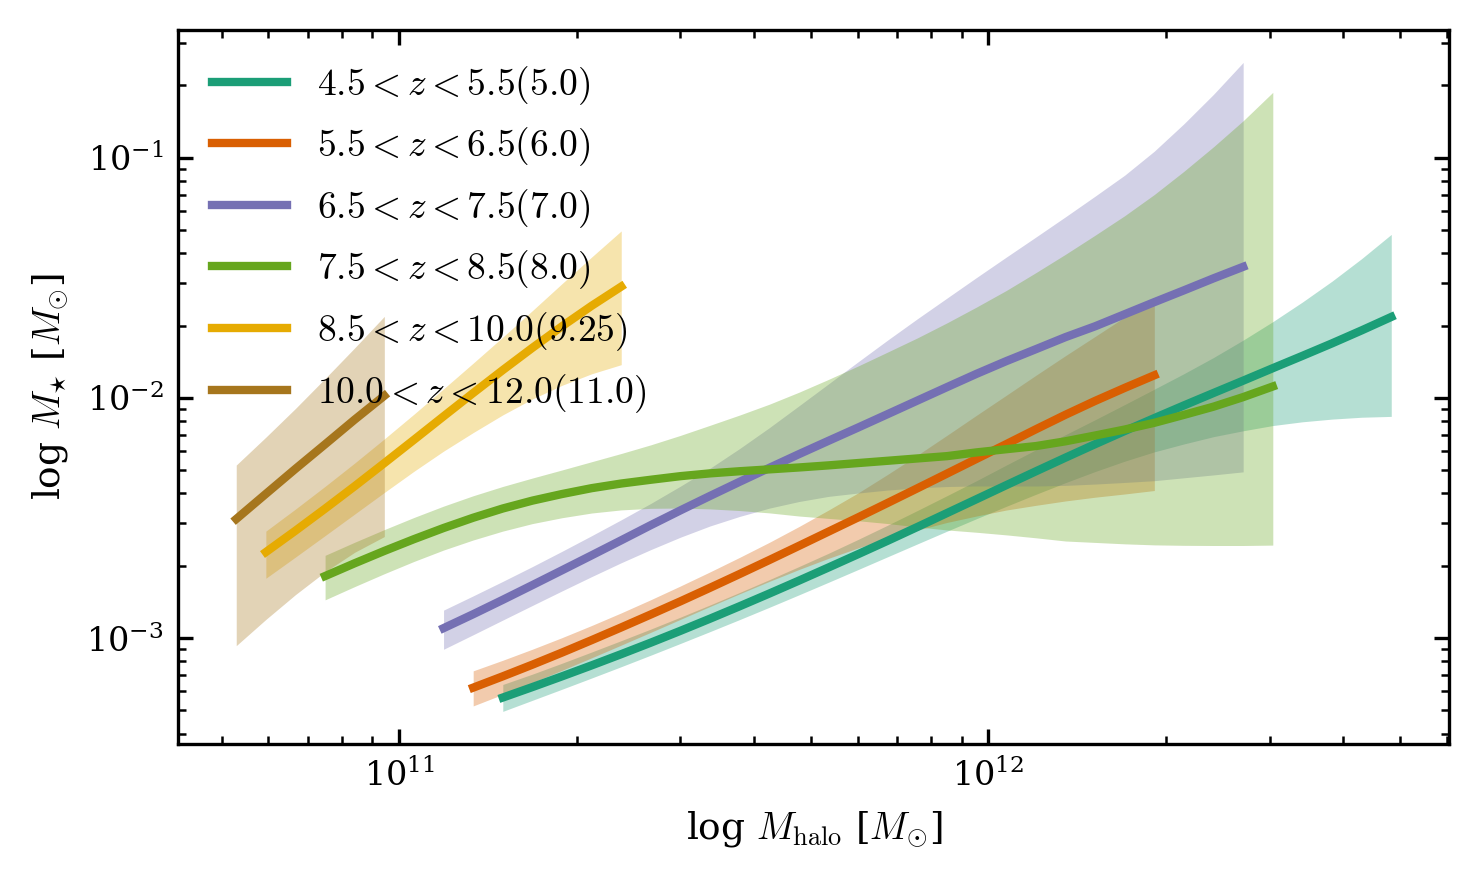

[11.0, 9.25, 8.0, 7.0, 6.0, 5.0, 0.05]


In [3]:
# read in behroozi data for comparison
smmr = np.loadtxt("./data/sm_averages_a1.002310.dat")
loghm = smmr[5:21, 0]  # halo mass
hm = 10**loghm * u.solMass

logSM = smmr[5:21, 7]  # stellar mass
sm = 10 ** logSM[5:21] * u.solMass

SMerr = np.vstack([smmr[5:21, 3], smmr[5:21, 2]])  # error array
logSMHM = smmr[5:21, 10]  # stellar mass / halo mass
SMHMerr = np.vstack([smmr[5:21, 12], smmr[5:21, 11]])  # error array

smhm_behroozi = 10**logSMHM / (Ob0 / Omegam0)
smhm_err_up = 10 ** SMHMerr[1, :]
smhm_err_low = 10 ** SMHMerr[0, :]


# define the redshift bins strings that will make it easier to read z-bins
zbins_str = [
    # "0.2 < z < 0.5",
    # "0.5 < z < 0.8",
    # "0.8 < z < 1.1",
    # "1.1 < z < 1.5",
    # "1.5 < z < 2.0",
    # "2.0 < z < 2.5",
    # "2.5 < z < 3.0",
    # "3.0 < z < 3.5",
    # "3.5 < z < 4.5",
    "4.5 < z < 5.5",
    "5.5 < z < 6.5",
    "6.5 < z < 7.5",
    "7.5 < z < 8.5",
    "8.5 < z < 10.0",
    "10.0 < z < 12.0",
]

# make a color map with the same number of colors as the number of zbins_str
cmap = plt.cm.Dark2
cmap_colors = [cmap(i / len(zbins_str)) for i in range(len(zbins_str))]

# get the center value of zbins_str
zbins_ctr = []
for zb in zbins_str:
    z = zb.split("<")
    z = (float(z[0]) + float(z[2])) / 2
    zbins_ctr.append(z)

## read the table
smf_data = Table.read("./data/Shuntov2024-shmr.ecsv", format="ascii.ecsv")

# define empty dictionaries to store values for each z-bin
Mhalo = {}
Mstar = {}
Mstar_low = {}
Mstar_up = {}

# read for each z-bin
for zb in zbins_str:
    Mhalo[zb] = smf_data[smf_data["Redshift"] == zb]["M_halo"]
    Mstar[zb] = smf_data[smf_data["Redshift"] == zb]["M_star_50"]
    Mstar_low[zb] = smf_data[smf_data["Redshift"] == zb]["M_star_16"]
    Mstar_up[zb] = smf_data[smf_data["Redshift"] == zb]["M_star_84"]


# Create a figure
fig, axs = plt.subplots(1, 1, figsize=(5, 3), dpi=300)
fig.subplots_adjust(hspace=0.00, wspace=1.000)


for i, zb in enumerate(zbins_str):
    smhm_shuntov = np.array(Mstar[zb]) / np.array(Mhalo[zb]) * (Ob0 / Omegam0)
    smhm_shuntov_low = np.array(Mstar_low[zb]) / np.array(Mhalo[zb]) * (Ob0 / Omegam0)
    smhm_shuntov_up = np.array(Mstar_up[zb]) / np.array(Mhalo[zb]) * (Ob0 / Omegam0)
    axs.plot(
        Mhalo[zb],
        smhm_shuntov,
        lw=2,
        alpha=1.0,
        color=cmap_colors[i],
        label=f"${zb} ({zbins_ctr[i]})$",
    )
    axs.fill_between(
        Mhalo[zb],
        smhm_shuntov_low,
        smhm_shuntov_up,
        lw=0,
        alpha=0.32,
        color=cmap_colors[i],
    )

# Set axes properties
axs.set_yscale("log")
axs.set_xscale("log")
# axs.set_ylim(1.0e-7, 0.2)
# axs.set_xlim(7.25, 12.2)
axs.set_ylabel(r"log $M_{\star}$ [$M_{\odot}$]")
axs.set_xlabel(r"log $M_{\rm halo}$ [$M_{\odot}$]")
axs.minorticks_on()
axs.legend(frameon=False)
plt.tight_layout()
plt.show()
# reverse zbins_ctr
zbins_ctr = zbins_ctr[::-1]
zbins_ctr.append(0.05)

# %%
# zobs = [12, 11]  # redshifts to observe at
# zobs = [8, 7, 3, 2, 1, 0.05]  # redshifts to observe at

zobs = zbins_ctr
print(zobs)
# make a unique halo arros for each redshift
mhalos = [
    np.geomspace(1e10, 1e13, 5) * u.Msun,
    np.geomspace(1e10, 1e13, 5) * u.Msun,
    np.geomspace(1e10, 1e13, 5) * u.Msun,
    np.geomspace(1e10, 1e13, 5) * u.Msun,
    np.geomspace(1e10, 1e13, 5) * u.Msun,
    np.geomspace(1e10, 1e13, 5) * u.Msun,
    np.geomspace(1e10, 1e13, 5) * u.Msun,
]  # halo mass for each redshift

## Newest model

In [ ]:
import h5py


def run_redshift_grid(observe_at, mhalos, write_to_file=None):
    eta_z = 0.3
    # observe these halos at a given redshift
    eta_m = 0.1
    eta_e = 0.1
    eta_z = 0.2
    # declare a 2d array to store the results
    # each row is a different redshift
    # each column is a different halo mass
    smhm_out = []
    zsims = []
    mhalo_obs_out = []
    mstar_obs_out = []
    mism_obs_out = []
    mcgm_hot_obs_out = []
    mcgm_cold_obs_out = []
    mbulge_obs_out = []
    for zidx, z_obs in enumerate(observe_at):
        t_init = 0.1  # Gyr
        # get the final time given the observed redshift
        t_final = LCDM.age(z_obs).value  # Gyr
        print("** t_final = {:.2f}".format(t_final))
        t_span = (t_init, t_final)  # span of the integration

        mhalo_obs = []
        mstar_obs = []
        mbulge_obs = []
        mism_obs = []
        mcgm_hot_obs = []
        mcgm_cold_obs = []

        # now, get the mass of the halo at z0 which is what we put into the integrator
        for midx, mhalo in enumerate(mhalos[zidx]):
            # we want to observe mhalo at z_obs, so we have to know its z=0 value for the function below
            mhalo_z0 = mhalo_at_z0(mhalo, z_obs) * u.Msun
            print("")
            print(
                "* observing halo with mass {:.2e} at z = {:.2f}".format(mhalo, z_obs)
            )
            print("** mass of halo at z=0 is {:.2e}".format(mhalo_z0))
            gridmodel = CGM_regulator(
                mhalo_z0, t_span, cooling_dynamic_time_norm=1, disk_scale_length=0.02
            )

            run = gridmodel.run_halo()
            results = gridmodel.get_results()
            m_star = results["m_star"][-1]
            m_bulge = results["m_bulge"][-1]
            m_halo = results["m_halo"][-1]
            print("** final halo mass = {:.2e}".format(m_halo))
            mhalo_obs.append(m_halo)
            mstar_obs.append(m_star)
            mbulge_obs.append(m_bulge)
            mism_obs.append(results["m_ism"][-1])
            mcgm_hot_obs.append(results["m_cgm_hot"][-1])
            mcgm_cold_obs.append(results["m_cgm_cold"][-1])

        mhalo_obs = np.array(mhalo_obs)
        mstar_obs = np.array(mstar_obs)
        mbulge_obs = np.array(mbulge_obs)
        mism_obs = np.array(mism_obs)
        mcgm_hot_obs = np.array(mcgm_hot_obs)
        mcgm_cold_obs = np.array(mcgm_cold_obs)

        # now put it into the output arrays
        mhalo_obs_out.append(mhalo_obs)
        mstar_obs_out.append(mstar_obs)
        mbulge_obs_out.append(mbulge_obs)
        mism_obs_out.append(mism_obs)
        mcgm_hot_obs_out.append(mcgm_hot_obs)
        mcgm_cold_obs_out.append(mcgm_cold_obs)

        smhm = mstar_obs / (mhalo_obs * (Ob0 / Omegam0))

        smhm_out.append(smhm)
        zsims.append(z_obs)

        # save as we go through the redshifts
        print(smhm_out)

    if write_to_file is not None:
        # commma separated string of the redshifts
        # z_string_formatted = ",".join([str(i) for i in observe_at])
        # mhalos_string_formatted = ",".join([str(i.value) for i in mhalos])
        # header_str = (
        #     "row redshifts = {}"
        #     "\n"
        #     "mhalos = {}".format(z_string_formatted, mhalos_string_formatted)
        # )

        # np.savetxt(write_to_file, smhm_out, header=header_str)
        # write to hdf5 file
        smhm_out = np.array(smhm_out)
        zsims = np.array(zsims)
        out_file = h5py.File(write_to_file, "w")
        out_file.create_dataset("redshifts", data=zsims)
        out_file.create_dataset("SMHM", data=smhm_out)
        out_file.create_dataset("Mhalo", data=mhalos)
        out_file.create_dataset("Mhalo_obs", data=mhalo_obs_out)
        # now do star mass, ism mass, cgm hot and cold masses
        out_file.create_dataset("Mstar_obs", data=mstar_obs_out)
        out_file.create_dataset("MISM_obs", data=mism_obs_out)
        out_file.create_dataset("MCGM_hot_obs", data=mcgm_hot_obs_out)
        out_file.create_dataset("MCGM_cold_obs", data=mcgm_cold_obs_out)
        # also write the m_bulge
        out_file.create_dataset("MBulge_obs", data=mbulge_obs_out)
        out_file.close()

    return smhm_out, zsims

In [5]:
redshift_variation, zsims = run_redshift_grid(
    zobs,
    mhalos,
    write_to_file="./runs/smhm_evolving-2phaseCGM.h5",
)

** t_final = 0.41

* observing halo with mass 1.00e+10 solMass at z = 11.00
** mass of halo at z=0 is 7.62e+12 solMass
_________________________________________
Running models from z = 29.69 redshift to z = 11.00 redshift
self.time_interval (0.1, 0.4089093982787829) tstep 1


/mnt/home/fgarcia/py_venves/camels/lib/python3.9/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/mnt/home/fgarcia/py_venves/camels/lib/python3.9/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Initial halo mass (t = 0.10 Gyr) = 2.19e+06 Msol
> initial values ISM  = 1.00e+03 Msol 	 Stellar mass = 1.00e+03 Msol	Bulge stellar mass = 1.00e+03 Msol	CGM hot mass = 1.00e+03 Msol	CGM cold mass = 1.00e+03 Msol	Metal mass = 2.68e-02 Msol	CGM metallicity = 0.0010 (Zsun)	Halo mass = 2.19e+06 Msol	ISM wind energy = 1.00e+03 erg	CGM cooling energy = 1.00e+03 erg	CGM out energy = 1.00e+03 erg	CGM in energy = 1.00e+03 erg	CGM energy = 6.00e+46 erg


/mnt/home/fgarcia/highzBHsandClusters/cgm_sf_regulator.py:81: RuntimeWarning: invalid value encountered in log10
  log_temp = np.log10(temperature)
/mnt/home/fgarcia/py_venves/camels/lib/python3.9/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in sqrt
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


*** Solution status: 0 (0: succes, -1: step failed, 1: termination )
Final halo mass = 1.94e+08 Msol	Initial halo mass = 2.19e+06 Msol	Final stellar mass = 2.37e+05 Msol	Peak halo scale efficiency = 2.37e-02	Final CGM mass = 7.85e+05 Msol	Final CGM metallicity = 1.39e-02	Final CGM energy = 7.50e+52 erg
** final halo mass = 1.94e+08

* observing halo with mass 5.62e+10 solMass at z = 11.00
** mass of halo at z=0 is 3.02e+14 solMass
_________________________________________
Running models from z = 29.69 redshift to z = 11.00 redshift
self.time_interval (0.1, 0.4089093982787829) tstep 1
Initial halo mass (t = 0.10 Gyr) = 4.45e+06 Msol
> initial values ISM  = 1.00e+03 Msol 	 Stellar mass = 1.00e+03 Msol	Bulge stellar mass = 1.00e+03 Msol	CGM hot mass = 1.00e+03 Msol	CGM cold mass = 1.00e+03 Msol	Metal mass = 2.68e-02 Msol	CGM metallicity = 0.0010 (Zsun)	Halo mass = 4.45e+06 Msol	ISM wind energy = 1.00e+03 erg	CGM cooling energy = 1.00e+03 erg	CGM out energy = 1.00e+03 erg	CGM in energy = 1

/mnt/home/fgarcia/py_venves/camels/lib/python3.9/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


*** Solution status: 0 (0: succes, -1: step failed, 1: termination )
Final halo mass = 1.74e+09 Msol	Initial halo mass = 8.42e+06 Msol	Final stellar mass = 5.13e+06 Msol	Peak halo scale efficiency = 1.87e-02	Final CGM mass = 8.33e+06 Msol	Final CGM metallicity = 4.95e-02	Final CGM energy = 3.90e+54 erg
** final halo mass = 1.74e+09

* observing halo with mass 1.78e+12 solMass at z = 11.00
** mass of halo at z=0 is 3.62e+19 solMass
_________________________________________
Running models from z = 29.69 redshift to z = 11.00 redshift
self.time_interval (0.1, 0.4089093982787829) tstep 1
Initial halo mass (t = 0.10 Gyr) = 1.49e+07 Msol
> initial values ISM  = 1.00e+03 Msol 	 Stellar mass = 1.00e+03 Msol	Bulge stellar mass = 1.00e+03 Msol	CGM hot mass = 1.00e+03 Msol	CGM cold mass = 1.00e+03 Msol	Metal mass = 2.68e-02 Msol	CGM metallicity = 0.0010 (Zsun)	Halo mass = 1.49e+07 Msol	ISM wind energy = 1.00e+03 erg	CGM cooling energy = 1.00e+03 erg	CGM out energy = 1.00e+03 erg	CGM in energy = 1

/mnt/home/fgarcia/highzBHsandClusters/cgm_sf_regulator.py:849: RuntimeWarning: invalid value encountered in scalar power
  dot_m_star = Asfr * sigma0**self.ks_n * (2 * np.pi * r_disk**2) / self.ks_n**2  # msun / Gyr
/mnt/home/fgarcia/highzBHsandClusters/cgm_sf_regulator.py:857: RuntimeWarning: invalid value encountered in scalar power
  dot_m_bulge = (2 * np.pi * Asfr * sigma0**self.ks_n) / self.ks_n**2


*** Solution status: 0 (0: succes, -1: step failed, 1: termination )
Final halo mass = 1.10e+09 Msol	Initial halo mass = 4.45e+06 Msol	Final stellar mass = 1.93e+06 Msol	Peak halo scale efficiency = 1.23e-02	Final CGM mass = 9.29e+06 Msol	Final CGM metallicity = 1.51e-02	Final CGM energy = 1.17e+54 erg
** final halo mass = 1.10e+09

* observing halo with mass 3.16e+11 solMass at z = 9.25
** mass of halo at z=0 is 1.63e+15 solMass
_________________________________________
Running models from z = 29.69 redshift to z = 9.25 redshift
self.time_interval (0.1, 0.5179098189282642) tstep 1
Initial halo mass (t = 0.10 Gyr) = 8.42e+06 Msol
> initial values ISM  = 1.00e+03 Msol 	 Stellar mass = 1.00e+03 Msol	Bulge stellar mass = 1.00e+03 Msol	CGM hot mass = 1.00e+03 Msol	CGM cold mass = 1.00e+03 Msol	Metal mass = 2.68e-02 Msol	CGM metallicity = 0.0010 (Zsun)	Halo mass = 8.42e+06 Msol	ISM wind energy = 1.00e+03 erg	CGM cooling energy = 1.00e+03 erg	CGM out energy = 1.00e+03 erg	CGM in energy = 1.0

## Old one single phase CGM

In [8]:
def run_baseline_model_redshift_grid(observe_at, mhalos, write_to_file=None):
    # declare a 2d array to store the results
    # each row is a different redshift
    # each column is a different halo mass
    smhm_out = []
    zsims = []
    mhalo_obs_out = []
    mstar_obs_out = []
    mism_obs_out = []

    for zidx, z_obs in enumerate(observe_at):
        t_init = 0.1  # Gyr
        # get the final time given the observed redshift
        t_final = LCDM.age(z_obs).value  # Gyr
        print("** t_final = {:.2f}".format(t_final))
        t_span = (t_init, t_final)  # span of the integration

        mhalo_obs = []
        mstar_obs = []
        mism_obs = []

        # now, get the mass of the halo at z0 which is what we put into the integrator
        for midx, mhalo in enumerate(mhalos[zidx]):
            # we want to observe mhalo at z_obs, so we have to know its z=0 value for the function below
            mhalo_z0 = mhalo_at_z0(mhalo, z_obs) * u.Msun
            print("")
            print(
                "* observing halo with mass {:.2e} at z = {:.2f}".format(mhalo, z_obs)
            )
            print("** mass of halo at z=0 is {:.2e}".format(mhalo_z0))
            gridmodel = CGMRegulatorBaseline(
                mhalo_z0,
                t_span,
                cooling_dynamic_time_norm=1,
            )

            run = gridmodel.run_halo()
            results = gridmodel.get_results()
            m_star = results["m_star"][-1]
            m_halo = results["m_halo"][-1]
            print("** final halo mass = {:.2e}".format(m_halo))

            mhalo_obs.append(m_halo)
            mstar_obs.append(m_star)
            mism_obs.append(results["m_gas"][-1])

        mhalo_obs = np.array(mhalo_obs)
        mstar_obs = np.array(mstar_obs)
        mism_obs = np.array(mism_obs)

        # now put it into the output arrays
        mhalo_obs_out.append(mhalo_obs)
        mstar_obs_out.append(mstar_obs)
        mism_obs_out.append(mism_obs)

        smhm = mstar_obs / (mhalo_obs * (Ob0 / Omegam0))

        smhm_out.append(smhm)
        zsims.append(z_obs)

        # save as we go through the redshifts
        print(smhm_out)

    if write_to_file is not None:
        # write to hdf5 file
        smhm_out = np.array(smhm_out)
        zsims = np.array(zsims)
        out_file = h5py.File(write_to_file, "w")
        out_file.create_dataset("redshifts", data=zsims)
        out_file.create_dataset("SMHM", data=smhm_out)
        out_file.create_dataset("Mhalo", data=mhalos)
        out_file.create_dataset("Mhalo_obs", data=mhalo_obs_out)
        # now do star mass, ism mass, cgm hot and cold masses
        out_file.create_dataset("Mstar_obs", data=mstar_obs_out)
        out_file.create_dataset("MISM_obs", data=mism_obs_out)
        out_file.close()

    return smhm_out, zsims


redshift_variation, zsims = run_baseline_model_redshift_grid(
    zobs,
    mhalos,
    write_to_file="./runs/smhm_baseline.h5",
)

** t_final = 0.41

* observing halo with mass 1.00e+10 solMass at z = 11.00
** mass of halo at z=0 is 7.62e+12 solMass
_________________________________________
Running models from z = 29.69 redshift to z = 11.00 redshift
self.time_interval (0.1, 0.4089093982787829) tstep 1
Initial halo mass (t = 0.10 Gyr) = 2.28e+07 Msol
> initial values ISM gas mass = 1.00e+03 Msol	Stellar mass = 1.00e+03 Msol	CGM mass = 1.00e+03 Msol	Metal mass = 1.34e-02 Msol	CGM metallicity = 0.0010 (Zsun)	Halo mass = 2.28e+07 Msol	ISM wind energy = 1.00e+03 erg	CGM cooling energy = 1.00e+03 erg	CGM out energy = 1.00e+03 erg	CGM in energy = 1.00e+03 erg	CGM energy = 2.86e+47 erg


/mnt/home/fgarcia/py_venves/camels/lib/python3.9/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


*** Solution status: 0 (0: succes, -1: step failed, 1: termination )
Final halo mass = 1.01e+10 Msol	Initial halo mass = 2.28e+07 Msol	Final stellar mass = 3.68e+07 Msol	Peak halo scale efficiency = 2.27e-02	Final CGM mass = 3.57e+08 Msol	Final CGM metallicity = 1.91e-02	Final CGM energy = 1.21e+56 erg
_________________________________________
** final halo mass = 1.01e+10

* observing halo with mass 5.62e+10 solMass at z = 11.00
** mass of halo at z=0 is 3.02e+14 solMass
_________________________________________
Running models from z = 29.69 redshift to z = 11.00 redshift
self.time_interval (0.1, 0.4089093982787829) tstep 1
Initial halo mass (t = 0.10 Gyr) = 5.64e+07 Msol
> initial values ISM gas mass = 1.00e+03 Msol	Stellar mass = 1.00e+03 Msol	CGM mass = 1.00e+03 Msol	Metal mass = 1.34e-02 Msol	CGM metallicity = 0.0010 (Zsun)	Halo mass = 5.64e+07 Msol	ISM wind energy = 1.00e+03 erg	CGM cooling energy = 1.00e+03 erg	CGM out energy = 1.00e+03 erg	CGM in energy = 1.00e+03 erg	CGM energ

/mnt/home/fgarcia/py_venves/camels/lib/python3.9/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Initial halo mass (t = 0.10 Gyr) = 5.40e+08 Msol
> initial values ISM gas mass = 1.00e+03 Msol	Stellar mass = 1.00e+03 Msol	CGM mass = 1.00e+03 Msol	Metal mass = 1.34e-02 Msol	CGM metallicity = 0.0010 (Zsun)	Halo mass = 5.40e+08 Msol	ISM wind energy = 1.00e+03 erg	CGM cooling energy = 1.00e+03 erg	CGM out energy = 1.00e+03 erg	CGM in energy = 1.00e+03 erg	CGM energy = 2.36e+48 erg
*** Solution status: 0 (0: succes, -1: step failed, 1: termination )
Final halo mass = 1.02e+13 Msol	Initial halo mass = 5.40e+08 Msol	Final stellar mass = 1.13e+11 Msol	Peak halo scale efficiency = 7.98e-02	Final CGM mass = 1.09e+12 Msol	Final CGM metallicity = 3.97e-02	Final CGM energy = 8.31e+60 erg
_________________________________________
** final halo mass = 1.02e+13
[array([0.02225479, 0.05924621, 0.09229599, 0.09179717, 0.06810566])]
** t_final = 0.52

* observing halo with mass 1.00e+10 solMass at z = 9.25
** mass of halo at z=0 is 1.85e+12 solMass
_________________________________________
Running mo

# read in available data if there

In [19]:
run_data = h5py.File("./runs/smhm_2phaseCGM-bulge_run.h5", "r")
run_data.keys()

<KeysViewHDF5 ['MBulge_obs', 'MCGM_cold_obs', 'MCGM_hot_obs', 'MISM_obs', 'Mhalo', 'Mhalo_obs', 'Mstar_obs', 'SMHM', 'redshifts']>

In [20]:
z = run_data["redshifts"][:]
print(z)
ism_mass = run_data["MISM_obs"][:]
hot_cgm_mass = run_data["MCGM_hot_obs"][:]
cold_cgm_mass = run_data["MCGM_cold_obs"][:]
observed_halo_mass = run_data["Mhalo_obs"][:]
observed_stellar_mass = run_data["Mstar_obs"][:]
observed_bulge_mass = run_data["MBulge_obs"][:]
smhm = observed_stellar_mass / (observed_halo_mass * (Ob0 / Omegam0))

[11.    9.25  8.    7.    6.    5.    0.05]


11.0 [0.06917602 0.21321587 0.26234683 0.23672591 0.17674015]
9.25 [0.04702166 0.20713435 0.28398341 0.26792261 0.20197434]
8.0 [0.04892898 0.19392888 0.29683064 0.29300506 0.22340081]
7.0 [0.03759367 0.17412128 0.30471526 0.31444723 0.24326972]
6.0 [0.03226809 0.14712923 0.3080563  0.33613159 0.26596006]
5.0 [0.02731135 0.11069174 0.30528413 0.35616033 0.29183084]
0.05 [0.0063771  0.01864522 0.06907542 0.24696672 0.4010361 ]


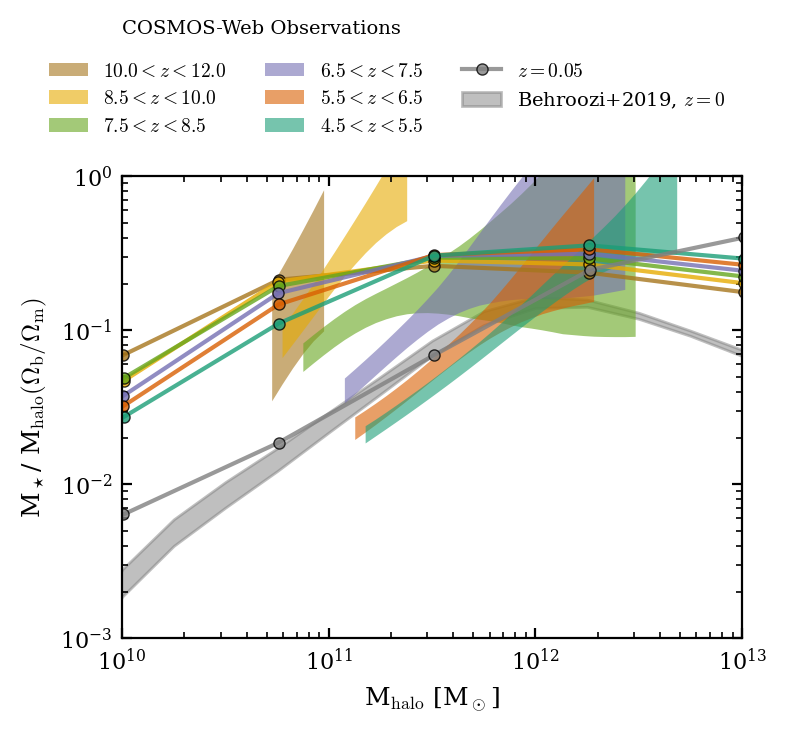

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3), dpi=200)

# Use the colors in the loop
for i, zb in enumerate(zbins_str[::-1]):

    smhm_shuntov = np.array(Mstar[zb]) / (np.array(Mhalo[zb]) * (Ob0 / Omegam0))
    smhm_shuntov_low = np.array(Mstar_low[zb]) / (np.array(Mhalo[zb]) * (Ob0 / Omegam0))
    smhm_shuntov_up = np.array(Mstar_up[zb]) / (np.array(Mhalo[zb]) * (Ob0 / Omegam0))
    ax.fill_between(
        Mhalo[zb],
        smhm_shuntov_low,
        smhm_shuntov_up,
        lw=0,
        alpha=0.6,
        color=cmap_colors[::-1][i],
        label=f"${zb}$",
    )

for i, smhm_model in enumerate(smhm):
    if zsims[i] < 1:  # only put label on the redshift ~ 0 run
        model_line_color = "grey"
        label = "$z = {:.2f}$".format(zsims[i])
    else:
        # we reverse the colors to match the observations, which put the lowest redshift first, :/
        model_line_color = cmap_colors[::-1][i]
        label = ""
    print(zsims[i], smhm_model)
    ax.plot(
        observed_halo_mass[i],
        smhm_model,
        markersize=4,
        marker="o",
        markeredgecolor="k",
        markeredgewidth=0.5,
        color=model_line_color,
        label=label,
        alpha=0.8,
    )

model_text = ""  # r"2 phase CGM model, Vcirc Energy and Mass Loading "
ax.text(
    0.95,
    0.1,
    model_text,
    transform=ax.transAxes,
    fontsize=6,
    verticalalignment="bottom",
    horizontalalignment="right",
)
ax.set(
    xlabel=r"M$_{\rm halo}$ [M$_\odot$]",
    ylabel=r"M$_\star$/ M$_{\rm halo} (\Omega_{\rm b}/\Omega_{\rm m})$",
    yscale="log",
    xscale="log",
    xlim=(1e10, 1e13),
    ylim=(1e-3, 1),
)
# ax.plot(10**loghm, 10**logSMHM, color="k", ls="--")
ax.fill_between(
    10**loghm,
    smhm_behroozi * smhm_err_low,
    smhm_behroozi * smhm_err_up,
    color="grey",
    alpha=0.5,
    label="Behroozi+2019, $z = 0$",
    zorder=0,
)

ax.legend(
    bbox_to_anchor=(1, 1.05), loc="lower right", ncol=3, frameon=False, fontsize=7
)

# add a text box for the the data
ax.text(
    0,
    1.3,
    "COSMOS-Web Observations",
    transform=ax.transAxes,
    fontsize=7,
    verticalalignment="bottom",
    horizontalalignment="left",
)

plt.savefig(
    "./figures/smhm_baseline.png",
    bbox_inches="tight",
    dpi=300,
    pad_inches=0.1,
)
plt.show()

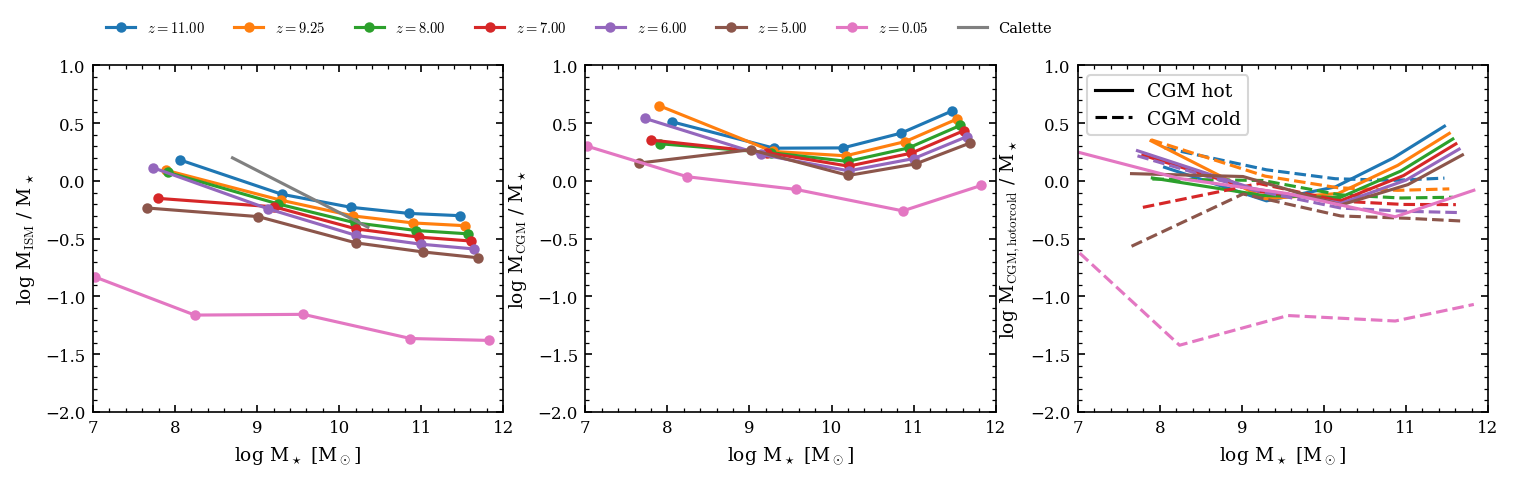

In [19]:
# fraction of ism mass to star mass as a function of stellar mass for each redshift
fig, ax = plt.subplots(1, 3, figsize=(12, 3), dpi=150)
for zidx, z_obs in enumerate(z):
    ism_mass_z = ism_mass[zidx, :]
    stellar_mass_z = observed_stellar_mass[zidx, :]
    cgm_mass_z = hot_cgm_mass[zidx, :] + cold_cgm_mass[zidx, :]
    hot_cgm_mass_z = hot_cgm_mass[zidx, :]
    cold_cgm_mass_z = cold_cgm_mass[zidx, :]
    ax[0].plot(
        np.log10(stellar_mass_z),
        np.log10(ism_mass_z / stellar_mass_z),
        marker="o",
        markersize=4,
        label=f"$z = {z_obs:.2f}$",
    )
    ax[1].plot(
        np.log10(stellar_mass_z),
        np.log10(cgm_mass_z / stellar_mass_z),
        marker="o",
        markersize=4,
        label=f"$z = {z_obs:.2f}$",
    )

    # now plot the hot and cold CGM masses separately
    hot_plot = ax[2].plot(
        np.log10(stellar_mass_z),
        np.log10(hot_cgm_mass_z / stellar_mass_z),
        ls="-",
    )
    # get the currect color from the previous plot
    cold_plot_color = hot_plot[0].get_color()
    ax[2].plot(
        np.log10(stellar_mass_z),
        np.log10(cold_cgm_mass_z / stellar_mass_z),
        ls="--",
        color=cold_plot_color,
    )

    # ax[1].plot(
    #     np.log10(observed_halo_mass[zidx, :]),
    #     np.log10(stellar_mass_z / (observed_halo_mass[zidx, :] * 0.16)),
    # )

ax[0].set(
    xlabel=r"log M$_\star$ [M$_\odot$]",
    ylabel=r"log M$_{\rm ISM}$ / M$_\star$",
    ylim=(-2, 1),
    xlim=(7, 12),
)
ax[1].set(
    xlabel=r"log M$_\star$ [M$_\odot$]",
    ylabel=r"log M$_{\rm CGM}$ / M$_\star$",
    ylim=(-2, 1),
    xlim=(7, 12),
)
ax[2].set(
    xlabel=r"log M$_\star$ [M$_\odot$]",
    ylabel=r"log M$_{\rm CGM, hot or cold}$ / M$_\star$",
    ylim=(-2, 1),
    xlim=(7, 12),
)
# indicate the hot and cold CGM lines for the dashed and solid lines
ax[2].plot([0, 1], [0, 0], ls="-", color="k", label="CGM hot")
ax[2].plot([0, 1], [0, 0], ls="--", color="k", label="CGM cold")

# make a line passing through (8.7, 0.322and (10.35, -0.5) and extend it to the left and right
ax[0].plot(
    [8.7, 10.35],
    [0.2, -0.4],
    ls="-",
    color="grey",
    label=r"Calette",
)

ax[2].legend()
ax[0].legend(
    bbox_to_anchor=(0, 1.05), loc="lower left", ncol=8, frameon=False, fontsize=7
)
plt.show()

### bulge mass function

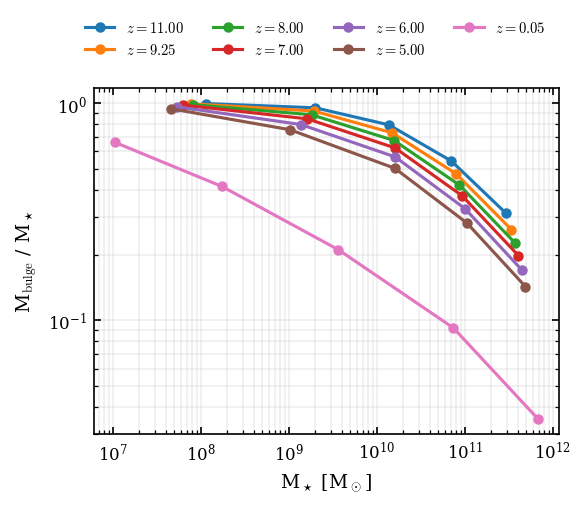

In [37]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3), dpi=150)
for zidx, z_obs in enumerate(z):
    ism_mass_z = ism_mass[zidx, :]
    stellar_mass_z = observed_stellar_mass[zidx, :]
    cgm_mass_z = hot_cgm_mass[zidx, :] + cold_cgm_mass[zidx, :]
    hot_cgm_mass_z = hot_cgm_mass[zidx, :]
    cold_cgm_mass_z = cold_cgm_mass[zidx, :]
    m_bugle_z = observed_bulge_mass[zidx, :]
    ax.plot(
        stellar_mass_z,
        m_bugle_z / stellar_mass_z,
        marker="o",
        markersize=4,
        label=f"$z = {z_obs:.2f}$",
    )

ax.set(
    xlabel=r"M$_\star$ [M$_\odot$]",
    ylabel=r"M$_{\rm bulge}$ / M$_\star$",
    xscale="log",
    yscale="log",
)
# add grid lines
ax.grid(which="both", ls="-", alpha=0.2)
ax.legend(
    bbox_to_anchor=(1, 1.05), loc="lower right", ncol=4, frameon=False, fontsize=7
)
plt.show()

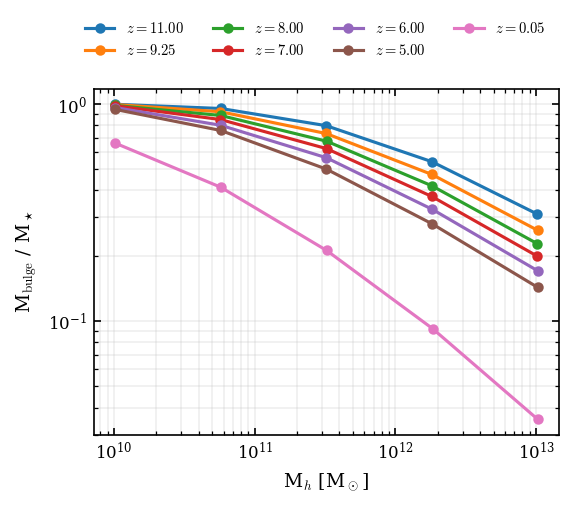

In [38]:
# now do the same but for the halo mass on the x axis
fig, ax = plt.subplots(1, 1, figsize=(4, 3), dpi=150)
for zidx, z_obs in enumerate(z):
    ism_mass_z = ism_mass[zidx, :]
    stellar_mass_z = observed_stellar_mass[zidx, :]
    cgm_mass_z = hot_cgm_mass[zidx, :] + cold_cgm_mass[zidx, :]
    hot_cgm_mass_z = hot_cgm_mass[zidx, :]
    cold_cgm_mass_z = cold_cgm_mass[zidx, :]
    m_bugle_z = observed_bulge_mass[zidx, :]
    ax.plot(
        observed_halo_mass[zidx, :],
        m_bugle_z / stellar_mass_z,
        marker="o",
        markersize=4,
        label=f"$z = {z_obs:.2f}$",
    )

ax.set(
    xlabel=r"M$_h$ [M$_\odot$]",
    ylabel=r"M$_{\rm bulge}$ / M$_\star$",
    xscale="log",
    yscale="log",
)
# add grid lines
ax.grid(which="both", ls="-", alpha=0.2)
ax.legend(
    bbox_to_anchor=(1, 1.05), loc="lower right", ncol=4, frameon=False, fontsize=7
)
plt.show()

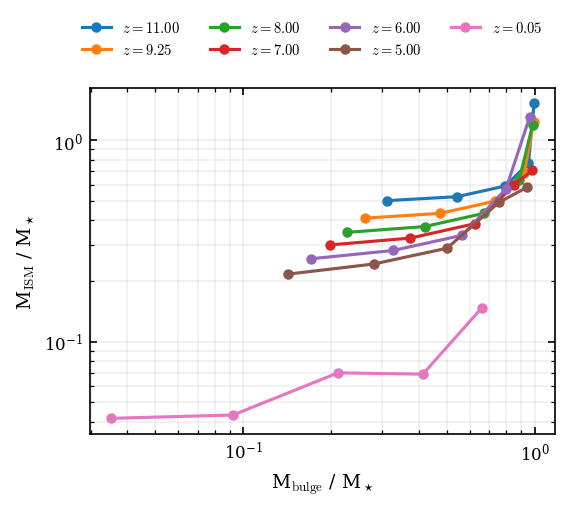

In [39]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3), dpi=150)
for zidx, z_obs in enumerate(z):
    ism_mass_z = ism_mass[zidx, :]
    stellar_mass_z = observed_stellar_mass[zidx, :]
    cgm_mass_z = hot_cgm_mass[zidx, :] + cold_cgm_mass[zidx, :]
    hot_cgm_mass_z = hot_cgm_mass[zidx, :]
    cold_cgm_mass_z = cold_cgm_mass[zidx, :]
    m_bugle_z = observed_bulge_mass[zidx, :]
    ax.plot(
        m_bugle_z / stellar_mass_z,
        ism_mass_z / stellar_mass_z,
        marker="o",
        markersize=4,
        label=f"$z = {z_obs:.2f}$",
    )

ax.set(
    ylabel=r"M$_{\rm ISM}$ / M$_\star$",
    xlabel=r"M$_{\rm bulge}$ / M$_\star$",
    xscale="log",
    yscale="log",
)
# add grid lines
ax.grid(which="both", ls="-", alpha=0.2)
ax.legend(
    bbox_to_anchor=(1, 1.05), loc="lower right", ncol=4, frameon=False, fontsize=7
)
plt.show()

### an evolving SMHM
meaning we see how a SMHM function with a set mass at z_0 evolves over time

[11.    9.25  8.    7.    6.    5.    0.05]
[[1.93670626e+08 5.99681679e+08 1.73800173e+09 4.67240003e+09
  1.16413195e+10]
 [3.32894397e+08 1.10200977e+09 3.42779843e+09 9.91626355e+09
  2.66302657e+10]
 [4.99167280e+08 1.74187999e+09 5.73278648e+09 1.75979147e+10
  5.02565390e+10]
 [6.98413327e+08 2.55080750e+09 8.81942421e+09 2.85288363e+10
  8.60727037e+10]
 [9.88112486e+08 3.78992117e+09 1.38236085e+10 4.73591593e+10
  1.51854767e+11]
 [1.41445301e+09 5.71865715e+09 2.21083162e+10 8.06837103e+10
  2.76871767e+11]
 [9.94335634e+09 5.58161000e+10 3.14757856e+11 1.76500976e+12
  9.84617661e+12]]


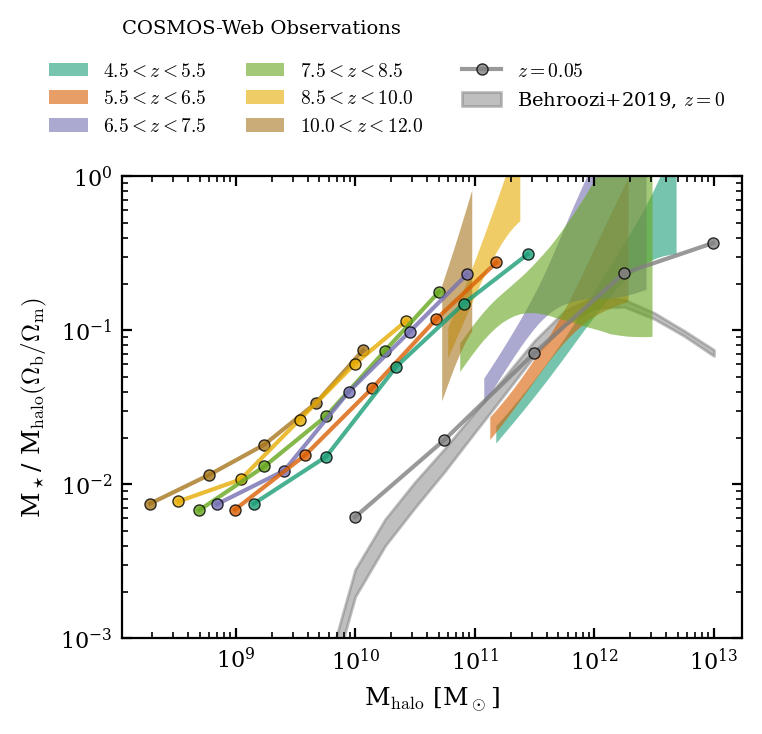

In [ ]:
evolving_data = h5py.File("./runs/smhm_evolving-2phaseCGM.h5", "r")
evolving_data.keys()
z = evolving_data["redshifts"][:]
ism_mass = evolving_data["MISM_obs"][:]
hot_cgm_mass = evolving_data["MCGM_hot_obs"][:]
cold_cgm_mass = evolving_data["MCGM_cold_obs"][:]
observed_halo_mass = evolving_data["Mhalo_obs"][:]
observed_stellar_mass = evolving_data["Mstar_obs"][:]
observed_bulge_mass = evolving_data["MBulge_obs"][:]
smhm = observed_stellar_mass / (observed_halo_mass * (Ob0 / Omegam0))
print(z)
print(observed_halo_mass)
fig, ax = plt.subplots(1, 1, figsize=(4, 3), dpi=200)

# Use the colors in the loop
for i, zb in enumerate(zbins_str[::]):
    smhm_shuntov = np.array(Mstar[zb]) / (np.array(Mhalo[zb]) * (Ob0 / Omegam0))
    smhm_shuntov_low = np.array(Mstar_low[zb]) / (np.array(Mhalo[zb]) * (Ob0 / Omegam0))
    smhm_shuntov_up = np.array(Mstar_up[zb]) / (np.array(Mhalo[zb]) * (Ob0 / Omegam0))
    ax.fill_between(
        Mhalo[zb],
        smhm_shuntov_low,
        smhm_shuntov_up,
        lw=0,
        alpha=0.6,
        color=cmap_colors[::][i],
        label=f"${zb}$",
    )

for i, smhm_model in enumerate(smhm):
    if zsims[i] < 1:  # only put label on the redshift ~ 0 run
        model_line_color = "grey"
        label = "$z = {:.2f}$".format(zsims[i])
    else:
        model_line_color = cmap_colors[::-1][i]
        label = ""

    ax.plot(
        observed_halo_mass[i],
        smhm_model,
        markersize=4,
        marker="o",
        markeredgecolor="k",
        markeredgewidth=0.5,
        color=model_line_color,
        label=label,
        alpha=0.8,
    )

model_text = ""  # r"2 phase CGM model, Vcirc Energy and Mass Loading "
ax.text(
    0.95,
    0.1,
    model_text,
    transform=ax.transAxes,
    fontsize=6,
    verticalalignment="bottom",
    horizontalalignment="right",
)
ax.set(
    xlabel=r"M$_{\rm halo}$ [M$_\odot$]",
    ylabel=r"M$_\star$/ M$_{\rm halo} (\Omega_{\rm b}/\Omega_{\rm m})$",
    yscale="log",
    xscale="log",
    # xlim=(1e10, 1e13),
    ylim=(1e-3, 1),
)
# ax.plot(10**loghm, 10**logSMHM, color="k", ls="--")
ax.fill_between(
    10**loghm,
    smhm_behroozi * smhm_err_low,
    smhm_behroozi * smhm_err_up,
    color="grey",
    alpha=0.5,
    label="Behroozi+2019, $z = 0$",
    zorder=0,
)
ax.legend(
    bbox_to_anchor=(1, 1.05), loc="lower right", ncol=3, frameon=False, fontsize=7
)

# add a text box for the the data
ax.text(
    0,
    1.3,
    "COSMOS-Web Observations",
    transform=ax.transAxes,
    fontsize=7,
    verticalalignment="bottom",
    horizontalalignment="left",
)
plt.show()

[11.    9.25  8.    7.    6.    5.    0.05]
[[1.01372100e+10 5.73553101e+10 3.21506083e+11 1.81337511e+12
  1.02030550e+13]
 [1.01937605e+10 5.69866994e+10 3.21141331e+11 1.81440271e+12
  1.02283744e+13]
 [1.01609358e+10 5.71530072e+10 3.24402710e+11 1.81497997e+12
  1.02122806e+13]
 [1.01392039e+10 5.70273574e+10 3.23758429e+11 1.81409856e+12
  1.02184486e+13]
 [1.01514230e+10 5.71220344e+10 3.22146622e+11 1.82590332e+12
  1.02335707e+13]
 [1.01566102e+10 5.71402884e+10 3.22387477e+11 1.81472917e+12
  1.02391450e+13]
 [1.01532263e+10 5.71831948e+10 3.23512080e+11 1.83421046e+12
  1.02541732e+13]]


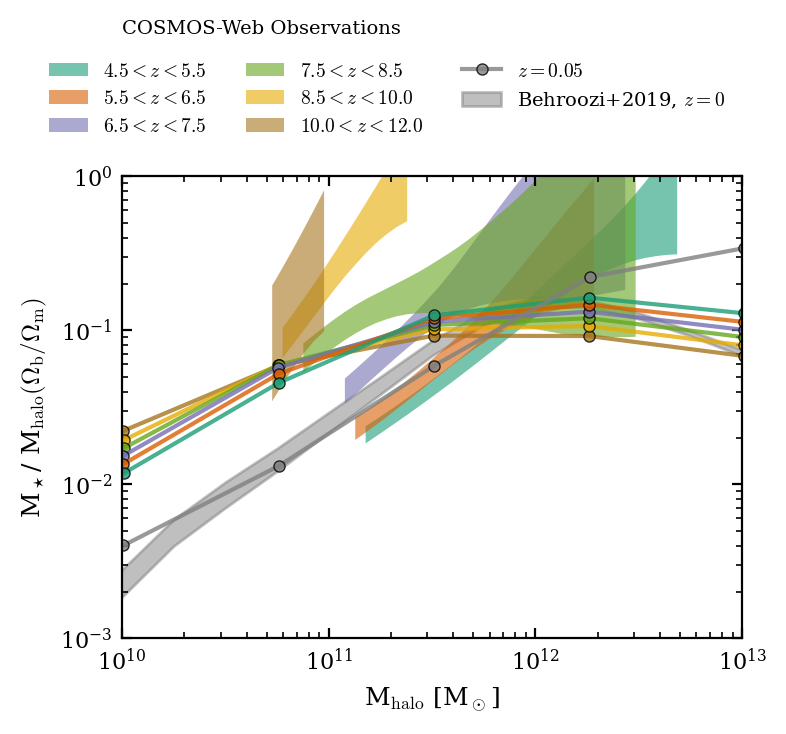

In [11]:
evolving_data = h5py.File("./runs/smhm_baseline.h5", "r")
evolving_data.keys()
z = evolving_data["redshifts"][:]
ism_mass = evolving_data["MISM_obs"][:]
observed_halo_mass = evolving_data["Mhalo_obs"][:]
observed_stellar_mass = evolving_data["Mstar_obs"][:]

smhm = observed_stellar_mass / (observed_halo_mass * (Ob0 / Omegam0))
print(z)
print(observed_halo_mass)
fig, ax = plt.subplots(1, 1, figsize=(4, 3), dpi=200)

# Use the colors in the loop
for i, zb in enumerate(zbins_str[::]):
    smhm_shuntov = np.array(Mstar[zb]) / (np.array(Mhalo[zb]) * (Ob0 / Omegam0))
    smhm_shuntov_low = np.array(Mstar_low[zb]) / (np.array(Mhalo[zb]) * (Ob0 / Omegam0))
    smhm_shuntov_up = np.array(Mstar_up[zb]) / (np.array(Mhalo[zb]) * (Ob0 / Omegam0))
    ax.fill_between(
        Mhalo[zb],
        smhm_shuntov_low,
        smhm_shuntov_up,
        lw=0,
        alpha=0.6,
        color=cmap_colors[::][i],
        label=f"${zb}$",
    )

for i, smhm_model in enumerate(smhm):
    if zsims[i] < 1:  # only put label on the redshift ~ 0 run
        model_line_color = "grey"
        label = "$z = {:.2f}$".format(zsims[i])
    else:
        model_line_color = cmap_colors[::-1][i]
        label = ""

    ax.plot(
        observed_halo_mass[i],
        smhm_model,
        markersize=4,
        marker="o",
        markeredgecolor="k",
        markeredgewidth=0.5,
        color=model_line_color,
        label=label,
        alpha=0.8,
    )

model_text = ""  # r"2 phase CGM model, Vcirc Energy and Mass Loading "
ax.text(
    0.95,
    0.1,
    model_text,
    transform=ax.transAxes,
    fontsize=6,
    verticalalignment="bottom",
    horizontalalignment="right",
)
ax.set(
    xlabel=r"M$_{\rm halo}$ [M$_\odot$]",
    ylabel=r"M$_\star$/ M$_{\rm halo} (\Omega_{\rm b}/\Omega_{\rm m})$",
    yscale="log",
    xscale="log",
    xlim=(1e10, 1e13),
    ylim=(1e-3, 1),
)
# ax.plot(10**loghm, 10**logSMHM, color="k", ls="--")
ax.fill_between(
    10**loghm,
    smhm_behroozi * smhm_err_low,
    smhm_behroozi * smhm_err_up,
    color="grey",
    alpha=0.5,
    label="Behroozi+2019, $z = 0$",
    zorder=0,
)
ax.legend(
    bbox_to_anchor=(1, 1.05), loc="lower right", ncol=3, frameon=False, fontsize=7
)

# add a text box for the the data
ax.text(
    0,
    1.3,
    "COSMOS-Web Observations",
    transform=ax.transAxes,
    fontsize=7,
    verticalalignment="bottom",
    horizontalalignment="left",
)
plt.show()